In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interact_manual

import sklearn as sk
import bertopic

ModuleNotFoundError: No module named 'sklearn'

# 1. Topic frequency

## Preparation

In [4]:
# read csv file with pandas
df = pd.read_csv('topics_per_month.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'topics_per_month.csv'

In [3]:
# Sum all frequency for each 'month' and return a new dataframe
total_frequency = df.groupby('Month').sum()['Frequency']
# Normalize frequency of each topic by the total frequency of each month and name it as 'norm_freq'
df['norm_freq'] = df.apply(lambda row: row['Frequency'] / total_frequency[row['Month']], axis=1)
# ranking of each topics for each month and name it as 'rank'
df['rank'] = df.groupby('Month')['norm_freq'].rank(ascending=False)

C:\Users\Seungwoong Ha\AppData\Local\Temp\ipykernel_11180\1892939431.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  total_frequency = df.groupby('Month').sum()['Frequency']


In [ ]:
# remove topic -1 from df and name it as 'df2'
df2 = df[df['Topic'] != -1]

In [19]:
# Do the same thing as above
total_frequency2 = df2.groupby('Month').sum()['Frequency']
df2['norm_freq'] = df.apply(lambda row: row['Frequency'] / total_frequency2[row['Month']], axis=1)
df2['rank'] = df2.groupby('Month')['norm_freq'].rank(ascending=False)


C:\Users\Seungwoong Ha\AppData\Local\Temp\ipykernel_11180\3099300160.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  total_frequency2 = df2.groupby('Month').sum()['Frequency']
C:\Users\Seungwoong Ha\AppData\Local\Temp\ipykernel_11180\3099300160.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['norm_freq'] = df.apply(lambda row: row['Frequency'] / total_frequency2[row['Month']], axis=1)
C:\Users\Seungwoong Ha\AppData\Local\Temp\ipykernel_11180\3099300160.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

## Visualization

### Total frequency

<AxesSubplot: title={'center': 'Total Frequency per Month'}, xlabel='Month'>

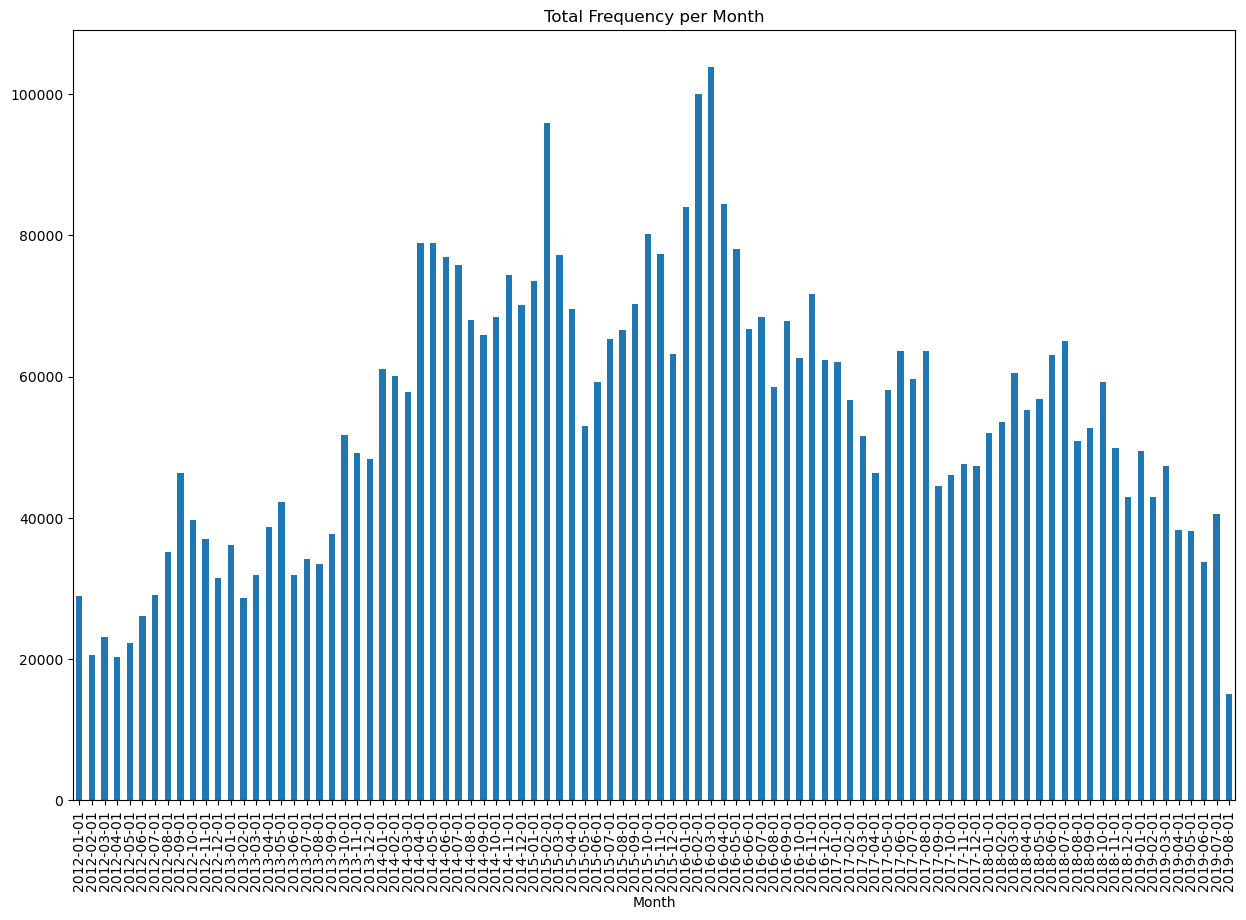

In [91]:
total_frequency.plot(kind='bar', figsize=(15, 10), title='Total Frequency per Month')

<AxesSubplot: title={'center': 'Total Frequency per Month'}, xlabel='Month'>

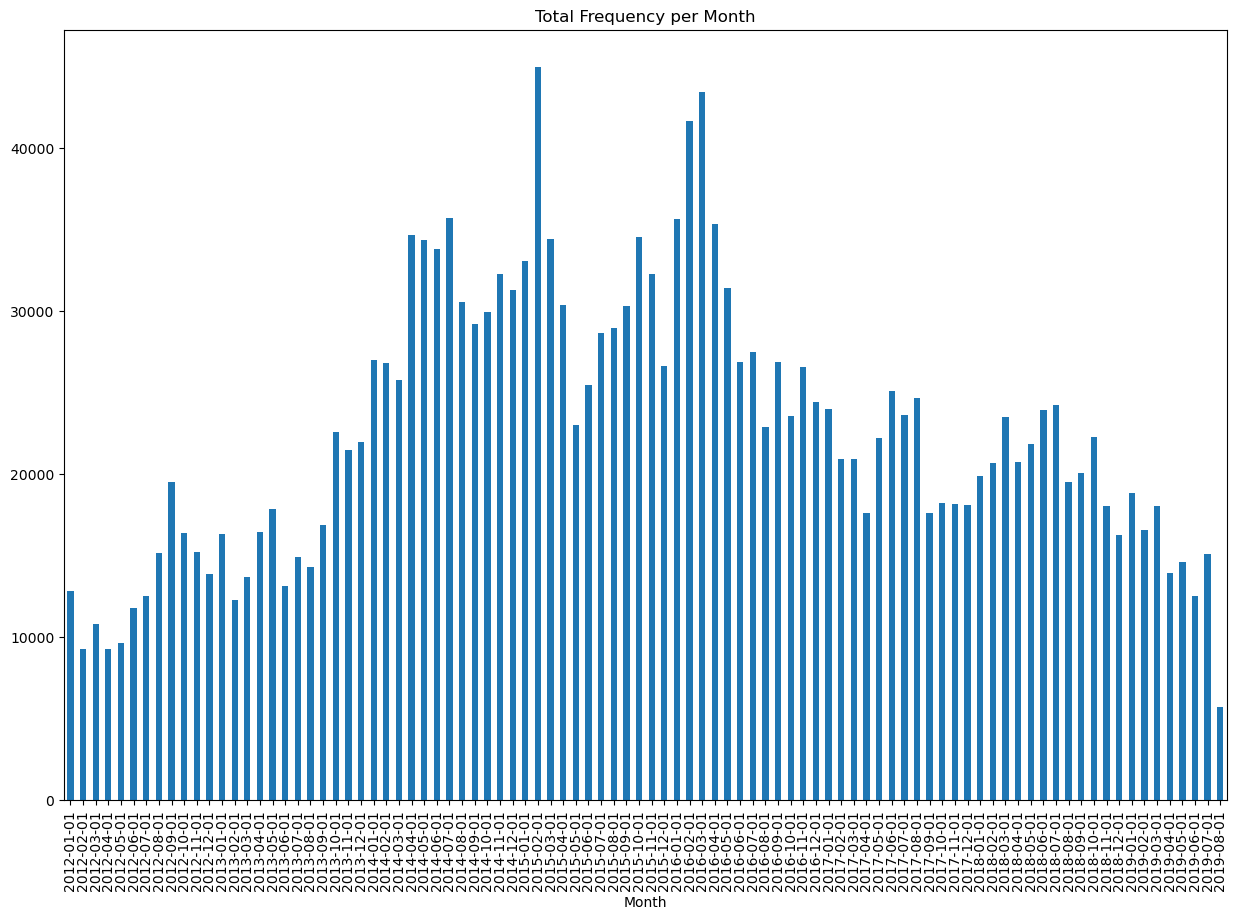

In [92]:
total_frequency2.plot(kind='bar', figsize=(15, 10), title='Total Frequency per Month')

### Ranking of each month

In [90]:
# take month as 'month' and plot the frequency of each topic sorted by 'rank' for that month. show only top N topics.
def plot_month(df, month, N=20):
    df[df['Month'] == month].sort_values('rank').head(N).plot(kind='bar', x='Topic', y='norm_freq', figsize=(15, 10), fontsize=12, title='Frequency of topics for month {}'.format(month))
    
    plt.xlabel('Topic', fontsize=14)
    plt.ylabel('normalized frequency', fontsize=14)
    
    # Get the text of current x tick labels and makes it as a list
    labels = [item.get_text() for item in plt.gca().get_xticklabels()]

    # Adding keywords at the end of the x tick labels
    keywords = (df[df['Month'] == month]['Words'].str.split(',').str[0])[:N]   
    labels = [f'{labels[i]}, {keywords.iloc[i]}' for i in range(N)]
    plt.xticks(range(N), labels, rotation=45)                

In [111]:
# with plot_month method, make a widget that shows the frequency of each topic sorted by 'rank' for each month.

months = df2['Month'].unique()
@interact
def plot_month_widget(month=months, N=20):
    plot_month(df2, month, N)

interactive(children=(Dropdown(description='month', options=('2012-01-01', '2012-02-01', '2012-03-01', '2012-0…

### Ranking / frequency of each topic

In [127]:
# take topic as 'topic' and plot the frequency of each topic for all months in the df.
def plot_topic(df, topic, ytype):
    months = df['Month'].unique()
    df[df['Topic'] == topic].plot(kind='bar', x='Month', y=ytype, figsize=(15, 10), fontsize=12, title='Frequency of topic {}'.format(topic))
    
    plt.xlabel('Month', fontsize=14)
    plt.ylabel(ytype, fontsize=14)

In [133]:
# with plot_month method, make a widget that shows the frequency of each topic sorted by 'rank' for each month.

topics = df2['Topic'].unique()
@interact
def plot_topic_widget(df=df2, topic=topics, ytype=['norm_freq', 'rank']):
    plot_topic(df2, topic, ytype)

interactive(children=(Dropdown(description='df', options=('Topic', 'Words', 'Frequency', 'Month', 'norm_freq',…

# 2. Topic embeddings

## Preparation

In [ ]:
# take all file names in /data/comments/valentin/topic-modeling-new-transform/motherjones as a list

path = '/data/comments/valentin/topic-modeling-new-transform/motherjones'
file_list = os.listdir(path)


In [ ]:
# string s is consist of 'MMYY'. Return the text string one month after.
def next_month(s):
    month = int(s[:2])
    year = int(s[2:])
    if month == 12:
        return '01' + str(year + 1)
    else:
        return str(month + 1).zfill(2) + str(year)

In [ ]:
total_mean_embedding_list= []
total_nonexist_index_list = []
for file_name in file_list:
    date = file_name.split('.')[0].split('-')[1]
    next_date = next_month(date)
    print(date)
    
    embedding_foler = '/data/comments/valentin/embeddings/'
    embedding_path = embedding_foler + f'motherjones/bert-emb-{date}-{next_date}.pt_createdAt.pt_artid'
    embedding = torch.load(embedding_path)

    topic_folder = '/data/comments/valentin/topic-modeling-new-transform/'
    topic_path = topic_folder + f'motherjones/batch-{date}.arrow'
    topic = pd.read_feather(topic_path)

    topic['embeddings'] = embedding['embeddings']

    mean_embedding_list = []
    nonexist_index_list = []
    for i in range(325):  # total 324 topics (excluding topic -1)
        current = topic[topic['topic']==i]
        if len(current)>0:
            averaged = torch.mean(torch.stack(list(current['embeddings'].values)), dim=0)
        else:
            nonexist_index_list.append(i)
            averaged = torch.zeros(384)  # dim. of embeddings
        mean_embedding_list.append(averaged.numpy())
        
    mean_embedding_list = np.array(mean_embedding_list)
    total_mean_embedding_list.append(mean_embedding_list)
    total_nonexist_index_list.append(nonexist_index_list)
    
total_mean_embedding_list = np.array(total_mean_embedding_list)

In [ ]:
# for each element of total_mean_embedding_list, remove all-zero rows (non-existing topics) and concatenate all of them.
embedding_list_tsne = []

for i, mean_embedding in enumerate(total_mean_embedding_list):
    mean_embedding = np.delete(mean_embedding, total_nonexist_index_list[i], axis=0)
    embedding_list_tsne.append(mean_embedding)
    
embedding_list_tsne = np.concatenate(embedding_list_tsne, axis=0)

In [ ]:
X_embedded = sk.manifold.TSNE(n_components=2).fit_transform(embedding_list_tsne)

In [ ]:
total_tsne_list = []
previous_list = np.array([[0, 0]] * 325)
counter = 0
for i in range(len(file_list)):
    print(i)
    tsne_list = []
    nonexist_index_list = total_nonexist_index_list[i]
    current_index = nonexist_index_list[0]
    for j in range(325):
        if j==current_index:
            tsne_list.append(previous_list[j])
            nonexist_index_list.pop(0)
            if len(nonexist_index_list)>0:
                current_index = nonexist_index_list[0]
        else:
            tsne_list.append(X_embedded[counter])
            previous_list[j] = X_embedded[counter]
            counter+=1
            
    assert len(tsne_list)==325
    total_tsne_list.append(np.array(tsne_list))
    
total_tsne_list = np.array(total_tsne_list)

In [ ]:
# save total_tsne_list
np.save('tsne.npy', total_tsne_list)

## Visualization

In [ ]:
total_tsne_list = np.load('tsne.npy')

In [ ]:
# visualizing total_tsne_list, which has 92 images of 325 points with 2d coordinates, with widgets.

date_list = []
for file_name in file_list:
    date_list.append(file_name.split('.')[0].split('-')[1])

# add toggle button to show the movement of points
# set default i to 0

jet_colors = plt.get_cmap('jet')(np.linspace(0, 1, 325))

@interact
def show_tsne(i=(0, 91), movement=True, total=True, focal=(0, 325)):
    fig = plt.figure(figsize=(5, 4), dpi=200)
    ax = fig.add_subplot(111)
    
    # Assign every point a different color on the jet colormap
    if total: 
        im = ax.scatter(total_tsne_list[i][:, 0], total_tsne_list[i][:, 1], c=np.arange(325), cmap='jet', s=5)
        # if i!=0, plot the previous points with alpha=0.2 to show the movement of points
        if movement and i!=0:
            ax.scatter(total_tsne_list[i-1][:, 0], total_tsne_list[i-1][:, 1], c=np.arange(325), cmap='jet', s=5, alpha=0.2)
            # draw arrows to show the movement of points with alpha 0.2, with arrowhead length 0.1
            for j in range(325):
                ax.arrow(total_tsne_list[i-1][j, 0], total_tsne_list[i-1][j, 1], total_tsne_list[i][j, 0]-total_tsne_list[i-1][j, 0], total_tsne_list[i][j, 1]-total_tsne_list[i-1][j, 1], color=jet_colors[j], head_width=1.5, alpha=0.2)
    else:
        # scatter a single point (focal) with color of focal point with jet colormap
    
        im = ax.scatter(total_tsne_list[i][:, 0], total_tsne_list[i][:, 1], c=np.arange(325), cmap='jet', s=5, alpha=0.2)
        im2 = ax.scatter(total_tsne_list[i][focal, 0], total_tsne_list[i][focal, 1], c=jet_colors[focal], s=10, alpha=1)
        # if i!=0, plot the previous points with alpha=0.2 to show the movement of points
        if movement and i!=0:
            ax.scatter(total_tsne_list[i-1][focal, 0], total_tsne_list[i-1][focal, 1], c=jet_colors[focal], s=10, alpha=0.5)
            # draw arrows to show the movement of points with alpha 0.2, with arrowhead length 0.1
            ax.arrow(total_tsne_list[i-1][focal, 0], total_tsne_list[i-1][focal, 1], total_tsne_list[i][focal, 0]-total_tsne_list[i-1][focal, 0], total_tsne_list[i][focal, 1]-total_tsne_list[i-1][focal, 1], head_width=2.5, alpha=1)

    
    ax.set_xlim(-120, 120)
    ax.set_ylim(-120, 120)
    # Add a colorbar to show the meaning of the colors
    ax.set_xlabel('TSNE 1')
    ax.set_ylabel('TSNE 2')
    ax.set_title(f'TSNE of 325 topics in {date_list[i][:2] + "/" + date_list[i][2:]}')
    
    # add a colorbar name
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Topic ID')
    
    plt.show()
# 174